GP_TensorFlow_CNN_Digits - Python - 2026-07-17 - DAMHAR2570

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_lfw_people
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
data = lfw_people.data
target = lfw_people.target
target_names = lfw_people.target_names

# Display dataset information
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")

### Step 1.2: Load the Dataset

Date: 2026-07-17

Student ID: DAMHAR2570

Data shape: (1288, 1850)
Number of classes: 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


### Step 1.3: Initial Exploration of the Dataset

Date: 2026-07-17

Student ID: DAMHAR2570

First few rows of the data:
[[0.9973857  0.99607843 0.9921568  ... 0.38169935 0.38823533 0.3803922 ]
 [0.14771242 0.19738562 0.1751634  ... 0.45751634 0.44444445 0.53594774]
 [0.34379086 0.39477125 0.49150327 ... 0.709804   0.72156864 0.7163399 ]
 [0.04705882 0.01699346 0.02352941 ... 0.06535948 0.14248367 0.20130719]
 [0.47189546 0.45882353 0.4862745  ... 0.07843138 0.2509804  0.2784314 ]]
Target values:
[5 6 3 1 0]


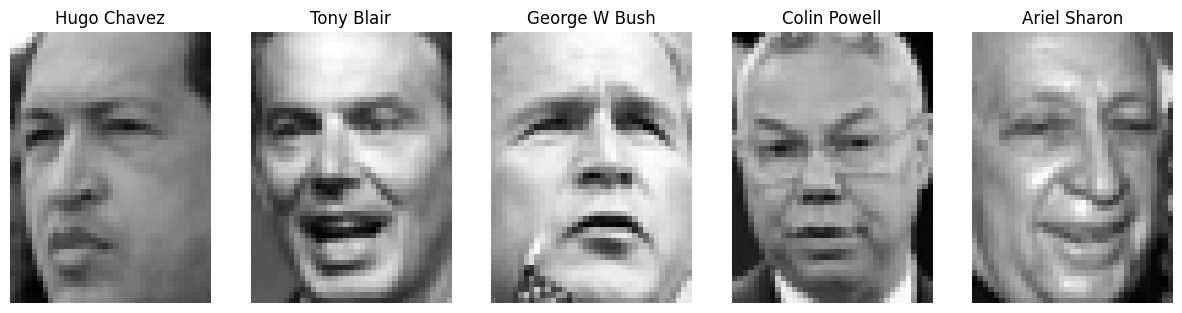

In [2]:
import matplotlib.pyplot as plt
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Display the first few rows of the data
print("First few rows of the data:")
print(data[:5])

# Display the target values
print("Target values:")
print(target[:5])

# Display the first few sample images with their target values
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    axes[i].imshow(data[i].reshape(50, 37), cmap='gray')
    axes[i].set_title(target_names[target[i]])
    axes[i].axis('off')
plt.show()

In [3]:
display(Markdown("### Step 1.4: Manual Feature Engineering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Normalize the pixel values
data = data / 255.0

# Add additional features if needed (e.g., pixel intensity statistics)
mean_pixel_values = np.mean(data, axis=1).reshape(-1, 1)
std_pixel_values = np.std(data, axis=1).reshape(-1, 1)

# Concatenate the new features with the original data
data_with_features = np.hstack((data, mean_pixel_values, std_pixel_values))
print(f"New data shape with engineered features: {data_with_features.shape}")

### Step 1.4: Manual Feature Engineering

Date: 2026-07-17

Student ID: DAMHAR2570

New data shape with engineered features: (1288, 1852)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
display(Markdown("### Step 2.1: Building the TensorFlow Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.2, random_state=42)

# Convert the target to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = tf.keras.utils.to_categorical(y_test, len(target_names))

# Build the neural network model
model = Sequential([Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), Dropout(0.5), Dense(128, activation='relu'), Dropout(0.5), Dense(len(target_names), activation='softmax')])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

### Step 2.1: Building the TensorFlow Model

Date: 2026-07-17

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         474,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 508,167 (1.94 MB)

 Trainable params: 508,167 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
display(Markdown("### Step 2.2: Training the TensorFlow Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Train the model
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.2)

# Save the model
model.save('face_recognition_model.h5')

### Step 2.2: Training the TensorFlow Model

Date: 2026-07-17

Student ID: DAMHAR2570

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3070 - loss: 1.9040 - val_accuracy: 0.4029 - val_loss: 1.7089
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3861 - loss: 1.7456 - val_accuracy: 0.4029 - val_loss: 1.6758
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4129 - loss: 1.7087 - val_accuracy: 0.4029 - val_loss: 1.6679
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4043 - loss: 1.7153 - val_accuracy: 0.4029 - val_loss: 1.6624
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4151 - loss: 1.6832 - val_accuracy: 0.4029 - val_loss: 1.6622
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4076 - loss: 1.6998 - val_accuracy: 0.4029 - val_loss: 1.6651
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3921 - loss: 1.7214 - val_accuracy: 0.4029 - val_loss: 1.6627
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3864 - loss: 1.7318 - val_accuracy: 0.4029 - v

### Step 2.3: Visualizing Model Performance

Date: 2026-07-17

Student ID: DAMHAR2570

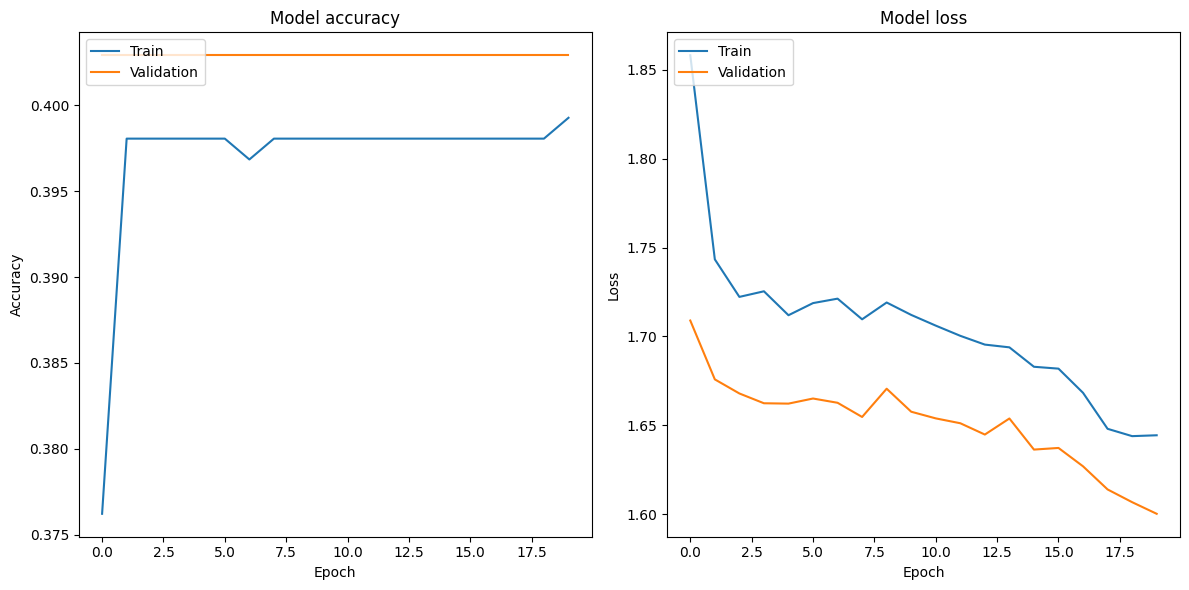

In [7]:
import matplotlib.pyplot as plt
display(Markdown("### Step 2.3: Visualizing Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.decomposition import PCA
display(Markdown("### Step 3.1: Advanced Feature Engineering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Perform PCA for dimensionality reduction
pca = PCA(n_components=150, whiten=True, random_state=42)
data_pca = pca.fit_transform(data)

# Add additional features if needed (e.g., pixel intensity statistics)
mean_pixel_values = np.mean(data_pca, axis=1).reshape(-1, 1)
std_pixel_values = np.std(data_pca, axis=1).reshape(-1, 1)

# Concatenate the new features with the PCA data
data_with_features = np.hstack((data_pca, mean_pixel_values, std_pixel_values))
print(f"New data shape with engineered features: {data_with_features.shape}")

### Step 3.1: Advanced Feature Engineering

Date: 2026-07-17

Student ID: DAMHAR2570

New data shape with engineered features: (1288, 152)


In [9]:
display(Markdown("### Step 3.2: Train the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.2, random_state=42)

# Convert the target to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = tf.keras.utils.to_categorical(y_test, len(target_names))

# Build the neural network model
model = Sequential([
Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), Dropout(0.5), Dense(128, activation='relu'), Dropout(0.5), Dense(len(target_names), activation='softmax')])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
PCA_history = model.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.2)

# Save the model
model.save('face_recognition_model_with_features.h5')

### Step 3.2: Train the Model

Date: 2026-07-17

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1928 - loss: 2.3781 - val_accuracy: 0.4126 - val_loss: 1.6884
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3267 - loss: 1.8567 - val_accuracy: 0.4515 - val_loss: 1.5776
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4134 - loss: 1.6027 - val_accuracy: 0.4709 - val_loss: 1.4904
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4960 - loss: 1.4349 - val_accuracy: 0.5534 - val_loss: 1.3772
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5811 - loss: 1.2533 - val_accuracy: 0.6117 - val_loss: 1.2742
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5840 - loss: 1.1590 - val_accuracy: 0.6408 - val_loss: 1.1536
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6374 - loss: 0.9828 - val_accuracy: 0.6942 - val_loss: 1.0377
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7049 - loss: 0.8900 - val_accuracy: 0.7767 - val_los

### Step 3.3: Visualizing Model Performance

Date: 2026-07-17

Student ID: DAMHAR2570

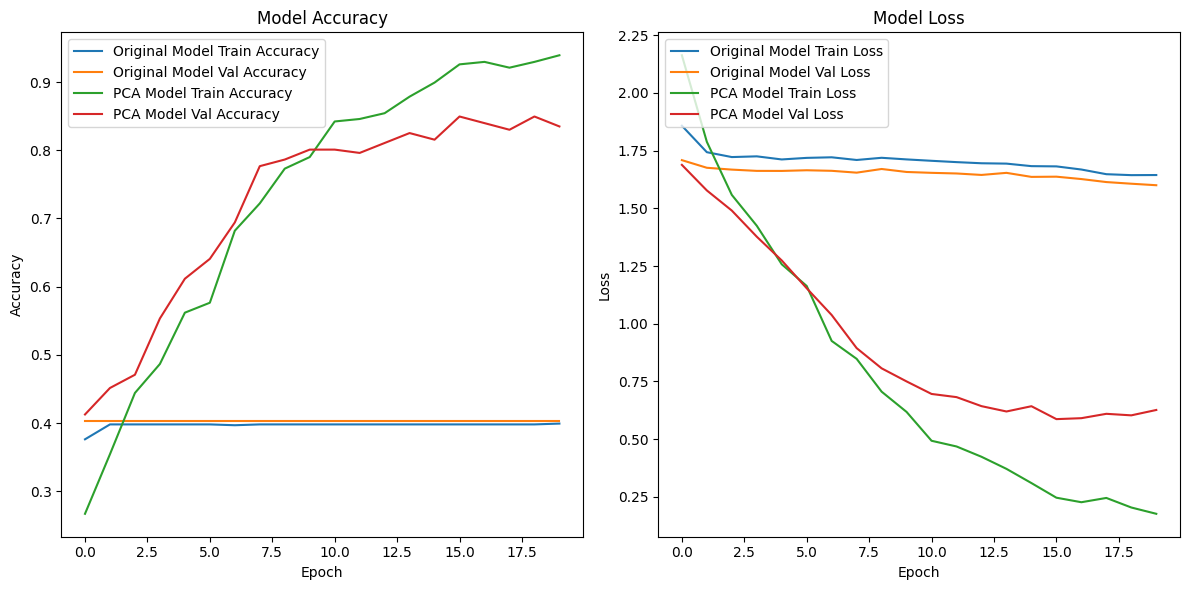

In [10]:
import matplotlib.pyplot as plt
display(Markdown("### Step 3.3: Visualizing Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot training & validation accuracy values for both old and new models
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Original Model Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Original Model Val Accuracy')
plt.plot(PCA_history.history['accuracy'], label='PCA Model Train Accuracy')
plt.plot(PCA_history.history['val_accuracy'], label='PCA Model Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values for both old and new models
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Original Model Train Loss')
plt.plot(history.history['val_loss'], label='Original Model Val Loss')
plt.plot(PCA_history.history['loss'], label='PCA Model Train Loss')
plt.plot(PCA_history.history['val_loss'], label='PCA Model Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
display(Markdown("### Step 3.4: Perform Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Define a function to create the model (required for KerasClassifier)
def create_model(optimizer='adam'):
    model = Sequential([Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), Dropout(0.5), Dense(128, activation='relu'), Dropout(0.5), Dense(len(target_names), activation='softmax')])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the KerasClassifier wrapper
model = KerasClassifier(model=create_model, optimizer='adam', epochs=20, batch_size=32, verbose=0)

# Define the grid search parameters
param_grid = {'optimizer': ['adam', 'rmsprop', 'sgd'], 'batch_size': [16, 32, 64], 'epochs': [5, 10, 15]}

# Initialize GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=- 1, cv=3)
grid_result = grid.fit(X_train, y_train_cat)

# Display the best parameters and best score
print(f"Best Parameters: {grid_result.best_params_}")
print(f"Best Score: {grid_result.best_score_}")

### Step 3.4: Perform Hyperparameter Tuning

Date: 2026-07-17

Student ID: DAMHAR2570

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Parameters: {'batch_size': 16, 'epochs': 15, 'optimizer': 'rmsprop'}
Best Score: 0.7815275611905892


### Step 3.5: Applying Best Parameters and Retraining the Model

Date: 2026-07-17

Student ID: DAMHAR2570

Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2643 - loss: 2.2313 - val_accuracy: 0.4515 - val_loss: 1.6080
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3853 - loss: 1.7377 - val_accuracy: 0.5243 - val_loss: 1.4534
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5004 - loss: 1.4121 - val_accuracy: 0.5680 - val_loss: 1.2916
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5548 - loss: 1.2516 - val_accuracy: 0.6456 - val_loss: 1.1315
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6710 - loss: 0.9701 - val_accuracy: 0.7767 - val_loss: 0.9311
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7255 - loss: 0.7763 - val_accuracy: 0.8155 - val_loss: 0.7784
Epoch 7/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8088 - loss: 0.6386 - val_accuracy: 0.8010 - val_loss: 0.7837
Epoch 8/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8358 - loss: 0.5443 - val_accuracy: 0.8350 - val_los

9/9 - 0s - 23ms/step - accuracy: 0.8488 - loss: 0.6351
Test accuracy: 0.8488371968269348


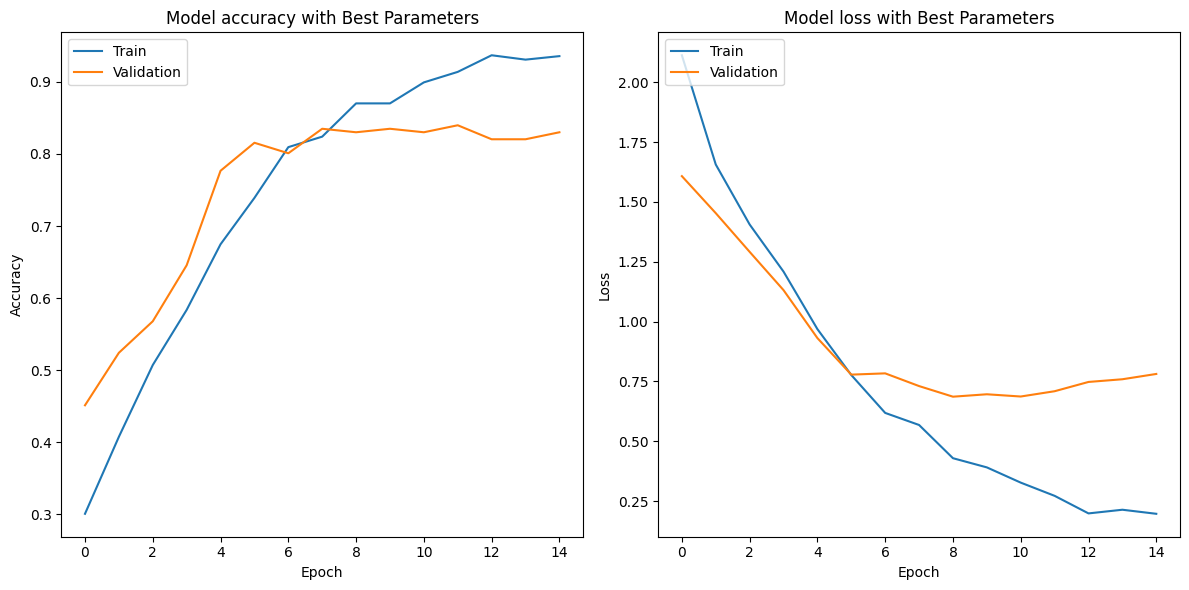

In [12]:
display(Markdown("### Step 3.5: Applying Best Parameters and Retraining the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Apply the best parameters
best_params = grid_result.best_params_

# Retrain the model with the best parameters
best_model = create_model(optimizer=best_params['optimizer'])
HP_history = best_model.fit(X_train, y_train_cat, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_split=0.2, verbose=1)

# Save the best model
best_model.save('best_face_recognition_model.h5')

# Evaluate the model on the test set
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc}")

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(HP_history.history['accuracy'])
plt.plot(HP_history.history['val_accuracy'])
plt.title('Model accuracy with Best Parameters')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(HP_history.history['loss'])
plt.plot(HP_history.history['val_loss'])
plt.title('Model loss with Best Parameters')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Step 3.6: Compare Optimized Model Performances

Date: 2026-07-17

Student ID: DAMHAR2570

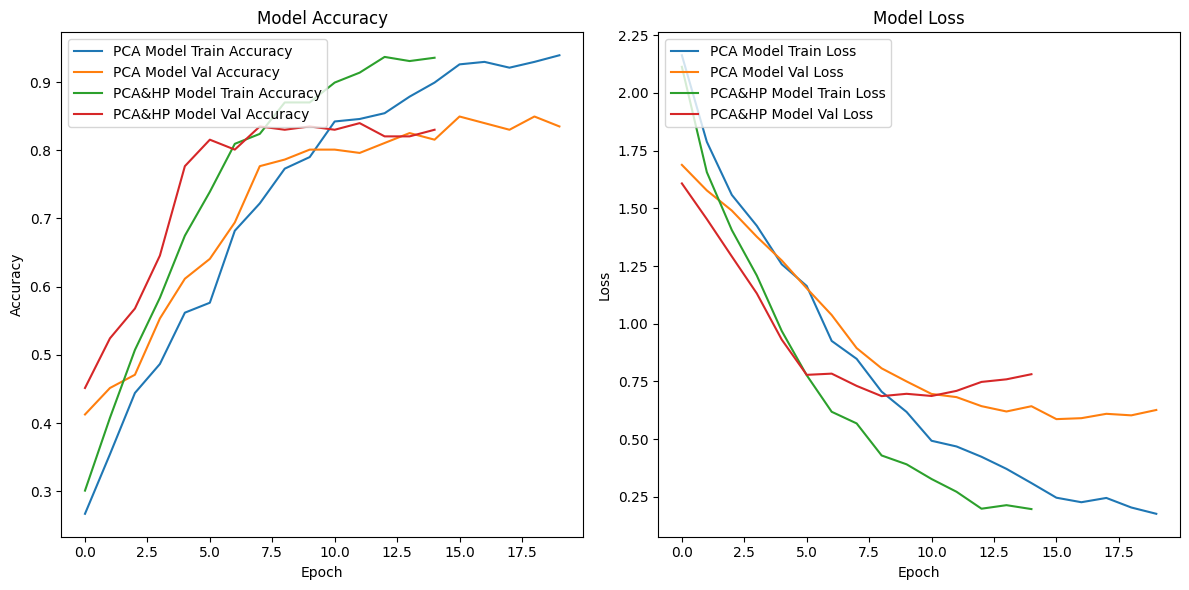

In [13]:
from sklearn.decomposition import PCA
display(Markdown("### Step 3.6: Compare Optimized Model Performances"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot training & validation accuracy values for both old and new models
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(PCA_history.history['accuracy'], label='PCA Model Train Accuracy')
plt.plot(PCA_history.history['val_accuracy'], label='PCA Model Val Accuracy')
plt.plot(HP_history.history['accuracy'], label='PCA&HP Model Train Accuracy')
plt.plot(HP_history.history['val_accuracy'], label='PCA&HP Model Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values for both old and new models
plt.subplot(1, 2, 2)
plt.plot(PCA_history.history['loss'], label='PCA Model Train Loss')
plt.plot(PCA_history.history['val_loss'], label='PCA Model Val Loss')
plt.plot(HP_history.history['loss'], label='PCA&HP Model Train Loss')
plt.plot(HP_history.history['val_loss'], label='PCA&HP Model Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()